<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exploratory Data Analysis**

## Loading the Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [44]:
# Import libararies
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
data=pd.read_csv('/content/drive/MyDrive/Customer_Churn_Data.csv')

## Understanding the dataset

### Overview

In [46]:
data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [47]:
data.shape

(7043, 21)

In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Missing Values Check

In [49]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Duplicate Row Check

In [50]:
data.duplicated().sum()

np.int64(0)

### Fixing Incorrect Datatypes and Missing value check after conversion

In [51]:
# Create a new numeric column for TotalCharges
data['TotalCharges_numeric'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Check missing values in the new numeric column
missing_total_charges = data['TotalCharges_numeric'].isnull().sum()
print(f"Missing values in TotalCharges_numeric after conversion: {missing_total_charges}")

# Check for duplicates
duplicate_rows = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Missing values in TotalCharges_numeric after conversion: 11
Number of duplicate rows: 0


Check if TotalCharges = MonthlyCharges * Tenure

In [52]:
# Create an estimated total charge
data['estimated_total'] = data['MonthlyCharges'] * data['tenure']

# Calculate absolute difference
data['difference'] = abs(data['TotalCharges_numeric'] - data['estimated_total'])

# Find the rows with the maximum difference
max_diff = data['difference'].max()
outliers = data[data['difference'] == max_diff]

# Drop the helper columns
data = data.drop(columns=['estimated_total', 'difference'])

# Print the maximum difference
print("Maximum difference between TotalCharges and MonthlyCharges*tenure:", max_diff)

Maximum difference between TotalCharges and MonthlyCharges*tenure: 373.2500000000009


### Summary Statistics  for numerical features

In [53]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges_numeric
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## Univarariate Analysis

### Target Variable

/tmp/ipython-input-1404788331.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


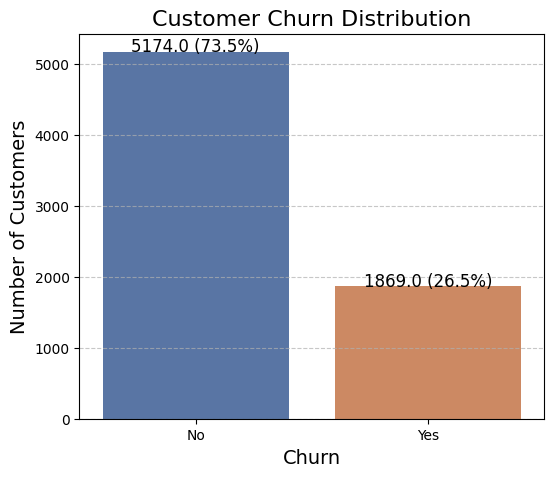

In [12]:
plt.figure(figsize=(6,5))
ax = sns.countplot(
    x='Churn',
    data=data,
    palette=['#4c72b0', '#dd8452']
)

# Add percentages
total = len(data)
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width()/2,
        y=height + 5,
        s=f'{height} ({height/total*100:.1f}%)',
        ha='center',
        fontsize=12
    )

# Labels and title
plt.xlabel('Churn', fontsize=14)
plt.ylabel('Number of Customers', fontsize=14)
plt.title('Customer Churn Distribution', fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Numerical Variable Distribution

Histograms

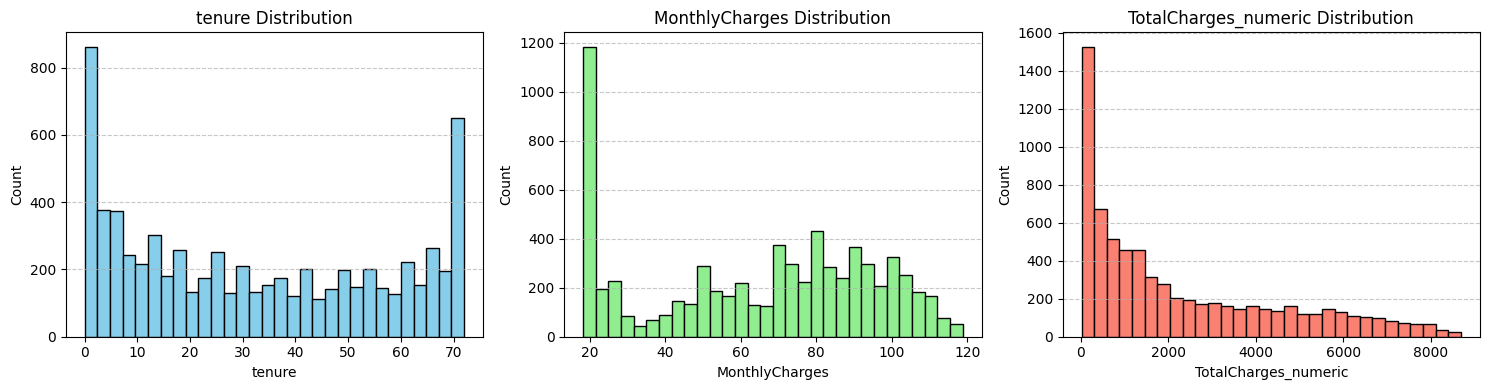

In [20]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges_numeric']
colors = ['skyblue', 'lightgreen', 'salmon']

plt.figure(figsize=(15, 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    plt.hist(data[col], bins=30, color=colors[i-1], edgecolor='black')
    plt.title(f'{col} Distribution', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Count', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Box Plots

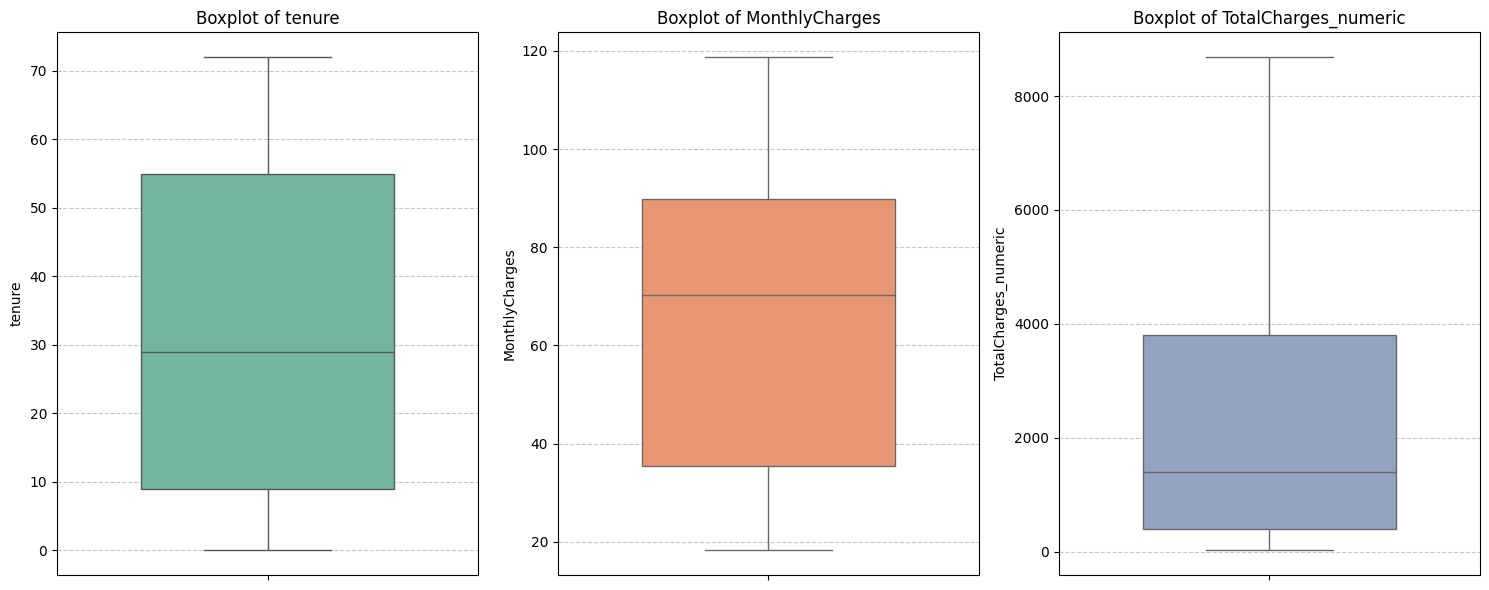

In [18]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges_numeric']

plt.figure(figsize=(15, 6))

colors = sns.color_palette("Set2", len(num_cols))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=data[col], color=colors[i-1], width=0.6, fliersize=4)
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.ylabel(col, fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Co-relation Heatmap

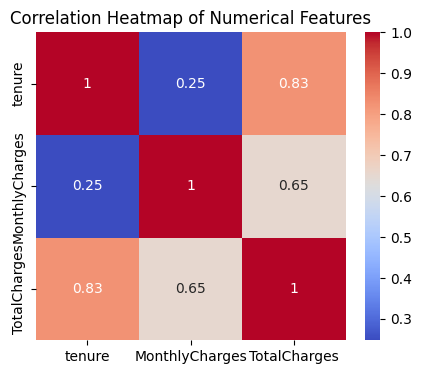

In [ ]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(5,4))
sns.heatmap(data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## Bivariate Analysis

Numerical Vs Churn

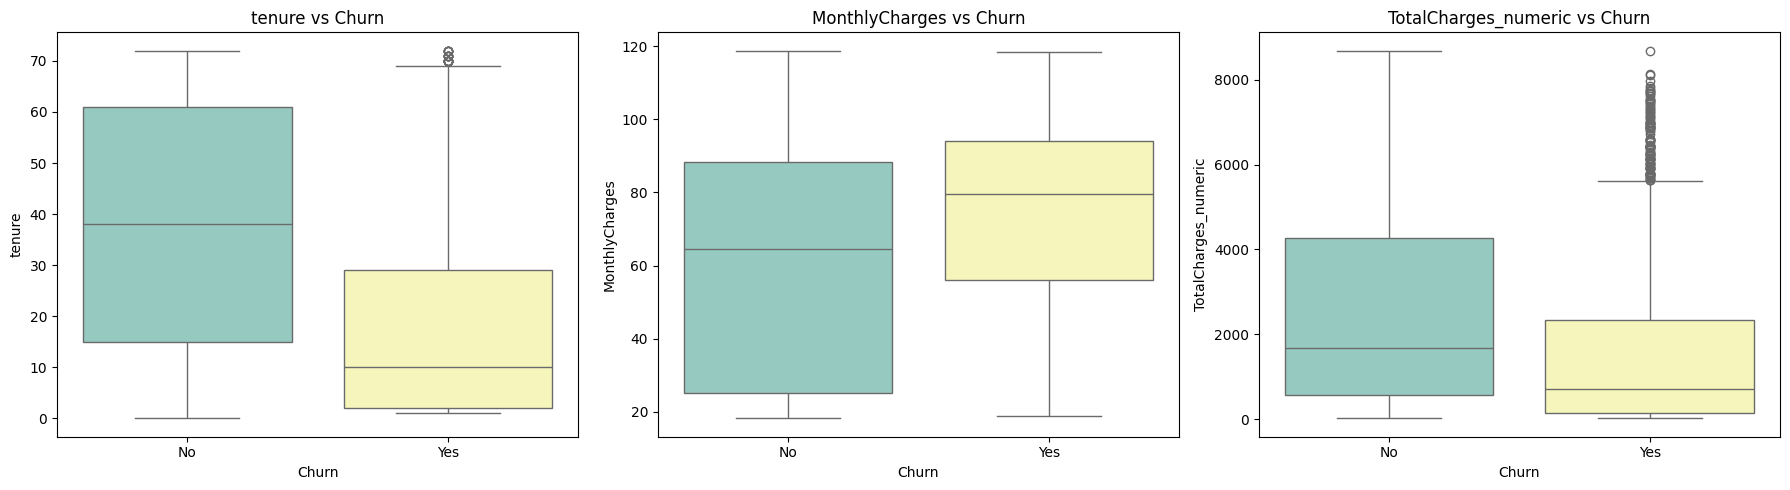

In [28]:
num_cols = ['tenure','MonthlyCharges','TotalCharges_numeric']

plt.figure(figsize=(18,5))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(
        x='Churn',
        y=col,
        data=data,
        palette='Set3'
    )
    plt.title(f'{col} vs Churn', fontsize=12)
    plt.xlabel('Churn')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

Categorical Vs Churn

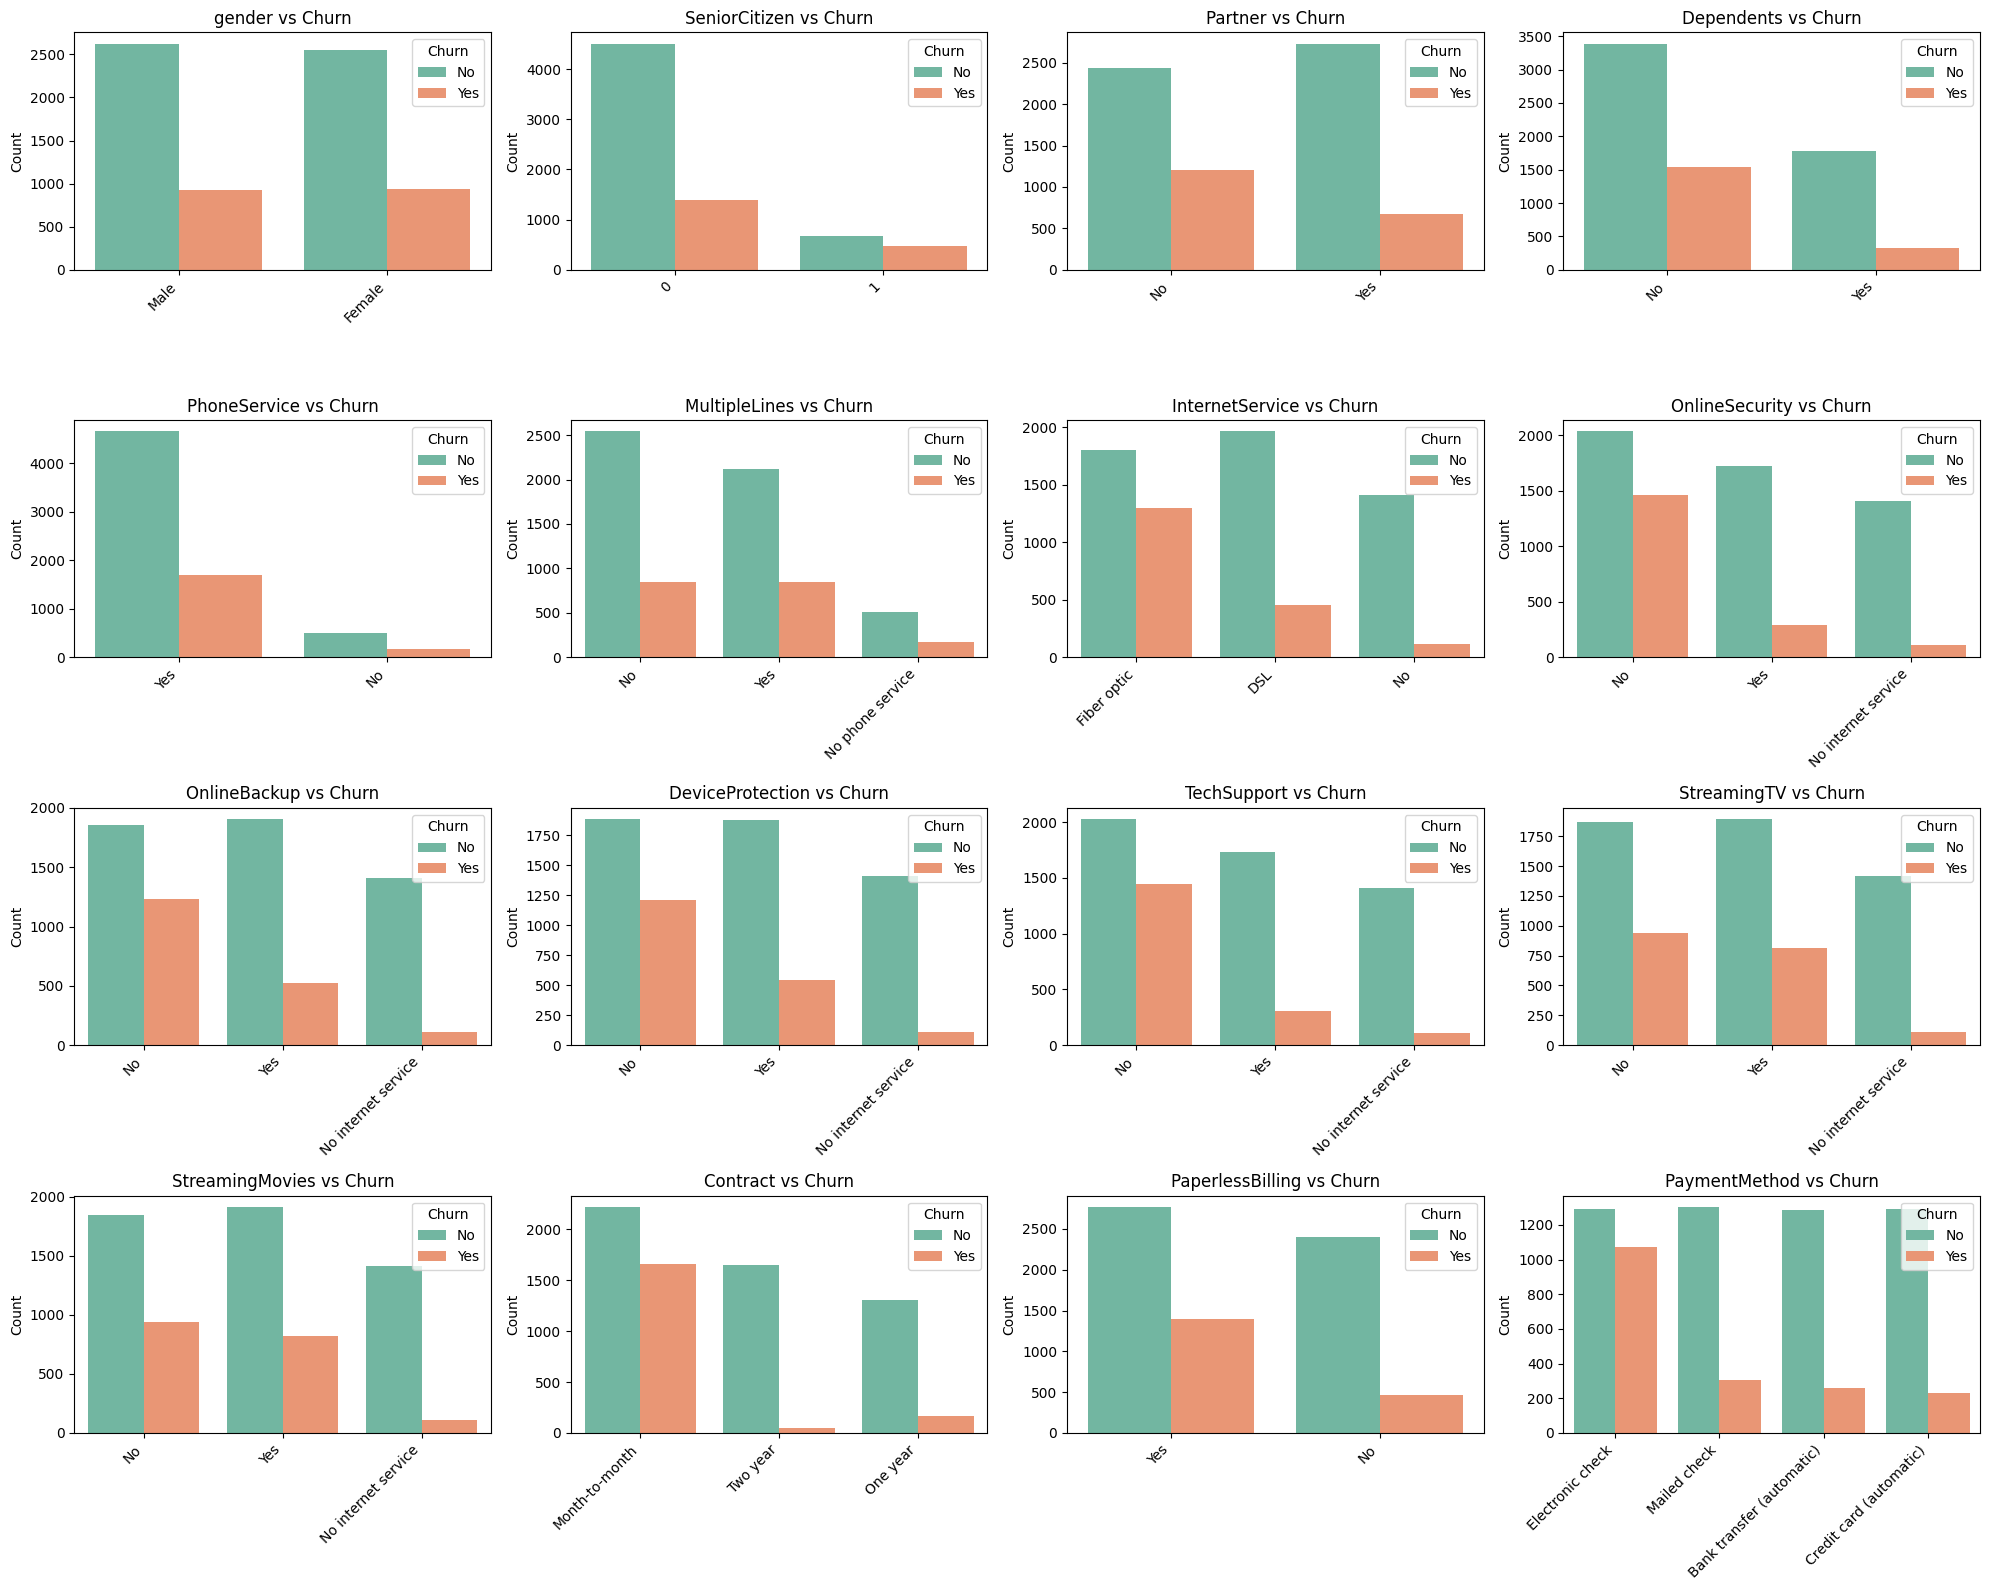

In [36]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

n_cols = 4
n_rows = -(-len(cat_cols) // n_cols)

plt.figure(figsize=(20, 4 * n_rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(
        data=data,
        x=col,
        hue='Churn',
        palette='Set2',
        order=data[col].value_counts().index
    )
    plt.title(f'{col} vs Churn', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Count')
    plt.xlabel('')

plt.tight_layout()
plt.show()